# LaSen 충실 재현 — 리포트 (5G-26, monostatic ISAC)

*자동 생성: `lasen/build_report.py`. 그림은 base64 내장 — 커널 없이 바로 보입니다.*

**원칙:** 충실(논문 eq/param) · 단계 게이트(각 phase가 figure로 자기증명 후 다음) · viz-first. **monostatic ISAC**(gNB tx≈rx, CFR H=Y/X) — 부모 bistatic 벤치마크와 별개. 충실/비충실 정직 구분: `docs/FAITHFULNESS.md`.

## Phase A — monostatic CFR → full-band 2D-FFT RD (sanity)   ·   GATE ✅ PASS

gNB가 알려진 5G-NR X를 송신·수신 → **CFR H=Y/X**(Eq 1). Sionna로 tx≈rx 씬 + 이동 드론 → CFR. slow-time 평균빼기로 **0-Hz 클러터/self-leakage 제거**(§4.1.1) → 2D-FFT RD맵.

설정: fc=5.8 GHz · B=78.12 MHz · SCS=30 kHz · FFT=3072 · active=2604 · **N(slow)=2803 실제 OFDM 심볼(R1)** · window=100 ms · PRF=28029 Hz · dopp_res=10 Hz.

### ① monostatic 기하 + ② NR 자원격자
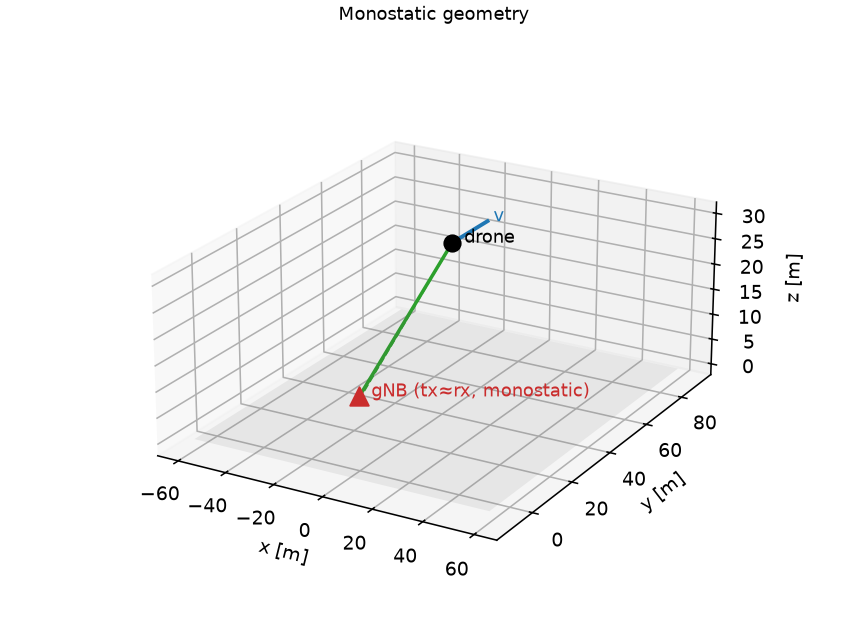
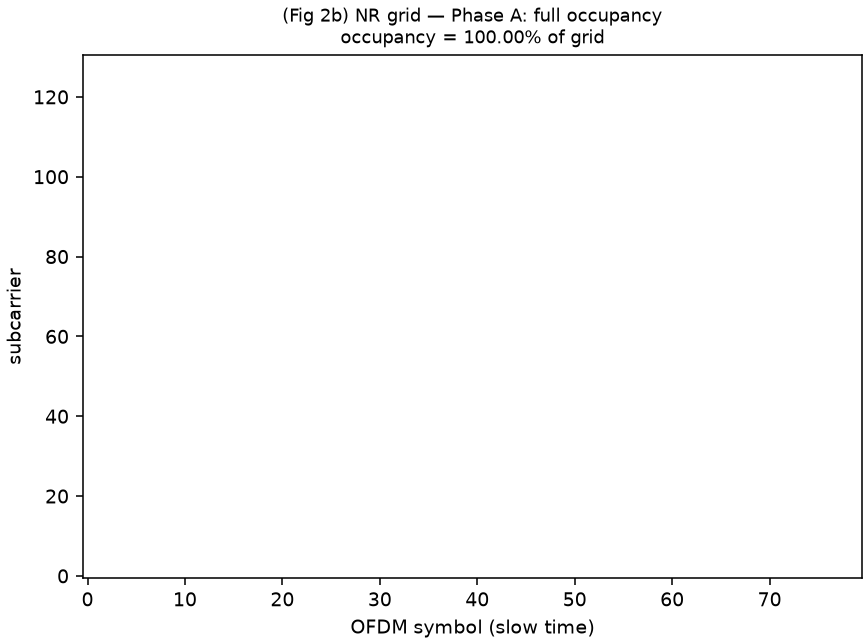
*왜:* gNB(tx≈rx)가 송·수신, 드론이 산란 → monostatic. **range=c·τ/2**(왕복지연→타깃거리), **Doppler=2v/λ**. Phase A는 **full occupancy**(모든 active RE 송신) — 비균일 점유 마스크는 Phase B.

### ③ CFR |H[t,f]| = Y/X  (Fig 3)
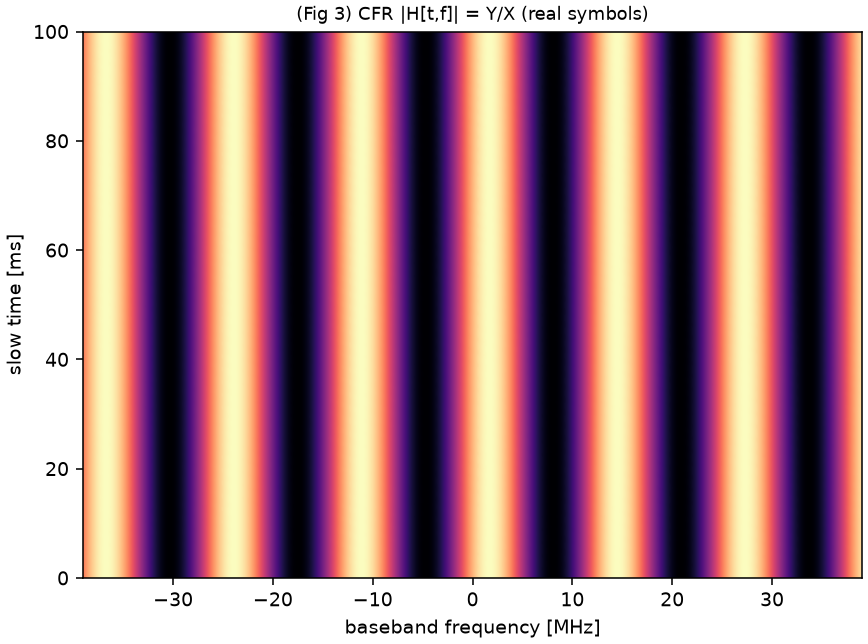
*왜:* 채널 주파수응답이 곧 H=Y/X(gNB는 X를 앎). 주파수축 줄무늬 = 지연(거리) 구조, slow-time축 = **실제 OFDM 심볼 2803개**(R1 — 점유 마스크·2D-OMP 사전이 이 위에 놓임).

### ④ RD: 정적억제 전 → 후  (Fig 4)
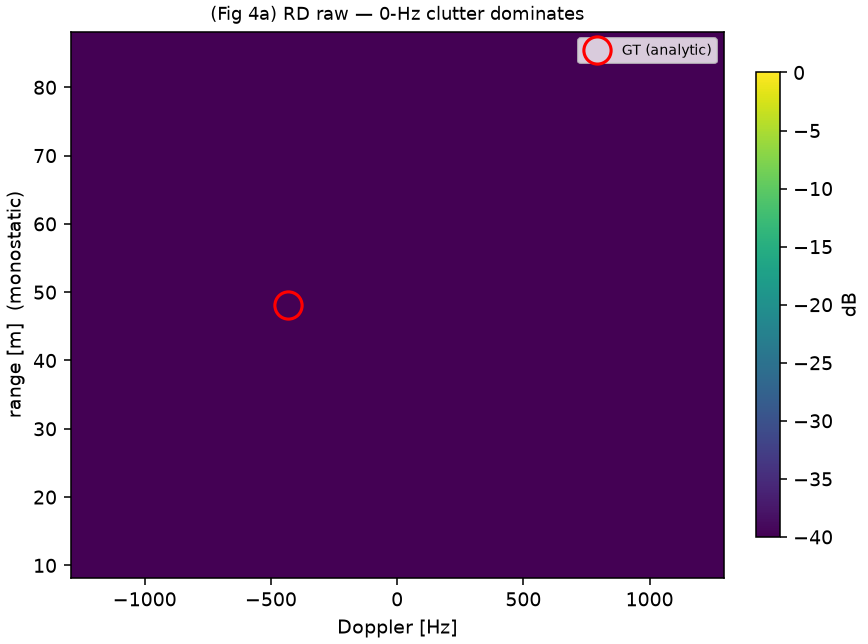
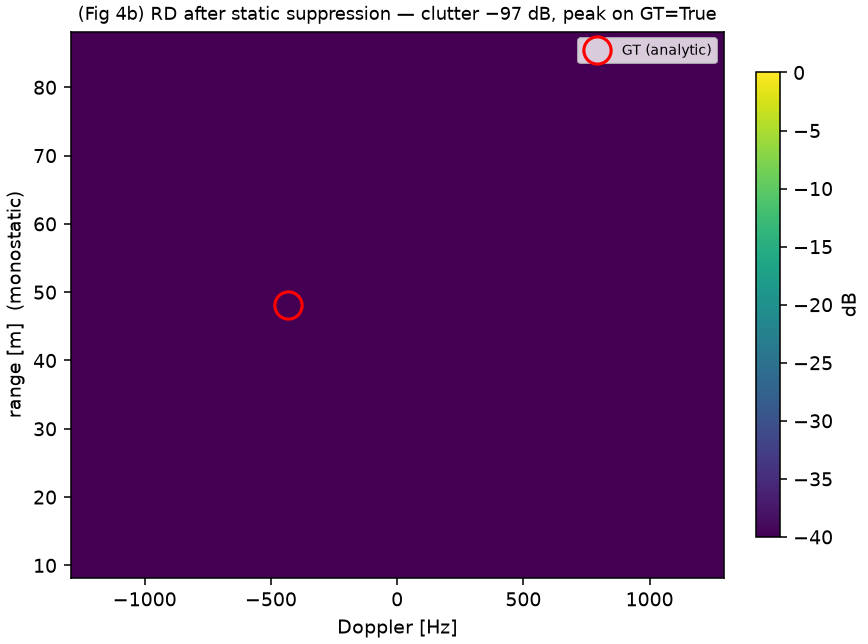
*왜:* 억제 전엔 **0-Hz 클러터/self-leakage가 지배**(드론 묻힘). slow-time 평균빼기 후 **0-Hz -97 dB 붕괴**(collapses) → 드론이 **GT 셀에 단일 피크**(range err 0.2 m, fD err 1.1 Hz, on_GT=True). LaSen Fig 4 재현.

### ⑤ Doppler↔velocity sweep  (R2 — 점 1개가 아니라 sweep)
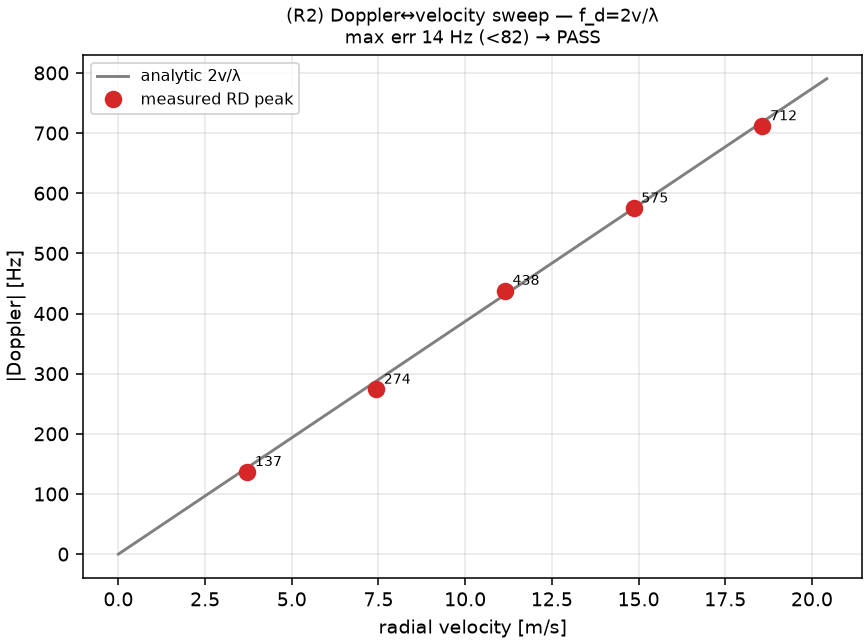
*왜:* 속도 4~20 m/s에서 측정 RD-peak Doppler가 해석적 **2v/λ** 선을 따라감 (max err **14 Hz**, pass=True). monostatic Doppler 법칙의 충실성을 1점이 아닌 추세로 증명.

→ **GATE ✅ PASS** (R1 실심볼 + R2 sweep + peak-on-GT + 클러터붕괴 모두 통과). 다음 = **Phase B**(비균일 점유 + 2D-OMP).

## Phase B — 비균일 점유 + 2D-OMP (핵심 novelty)   ·   GATE ✅ PASS

실제 5G 트래픽은 **비균일 점유**(전송된 RE만 관측) → masked CFR **ĥ = W∘H = Φz**(Eq 4-5). plain 2D-FFT는 미전송 RE를 0으로 두고 변환 → **sub-Nyquist 누설 바닥**(점유가 sparse할수록 악화); **2D-OMP**는 masked 관측을 sparse 모델로 적합(Eq 6) → **깨끗한 RD**(큰 동적범위). 점유밀도는 논문 측정 bin(sparse 3.7% / dense 16.2%).

- **omp2d round-trip sub-게이트**: PASS (rd_transform(atom(di,ri))이 정확히 (di,ri) 셀에 피크 — 부호·규약 일치).
- **게이트:** OMP가 양 밀도에서 표적 복원(예); OMP 동적범위 ≫ FFT(sparse ΔPSLR=113 dB); FFT 누설 바닥이 sparse에서 악화(43 < dense 49 dB).

### 점유 마스크 W (sparse vs dense) + 밀도 timeline
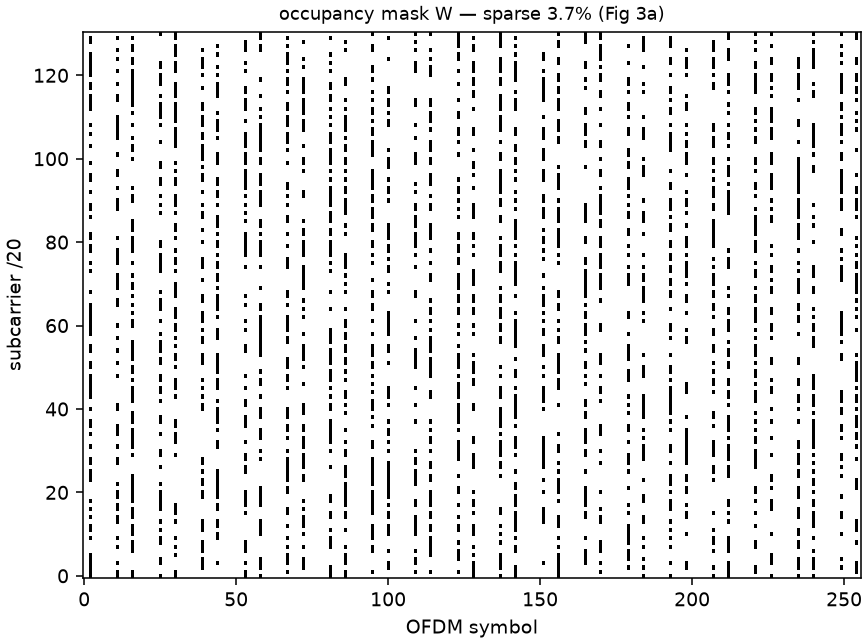
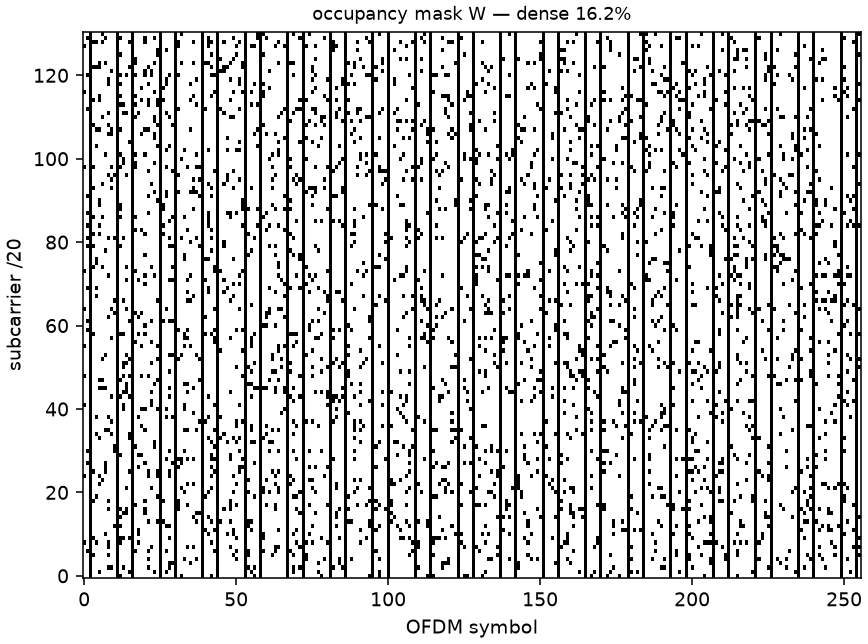
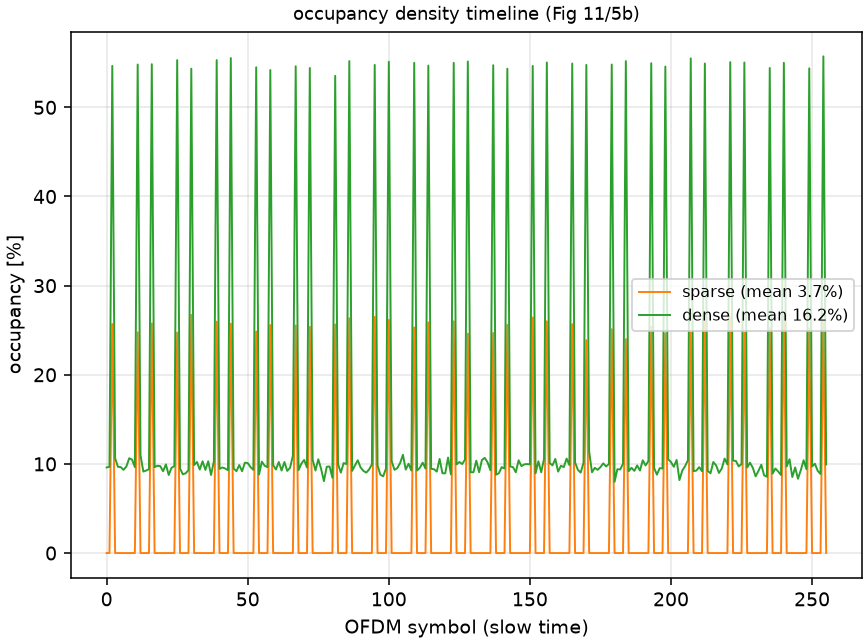
*왜:* DMRS comb은 항상, PDSCH 데이터는 트래픽 따라 — sparse일수록 관측 RE 급감(Fig 3a/11).

### RD 비교: 2D-FFT(누설) vs 2D-OMP(깨끗)  — money figure (Tab.1)
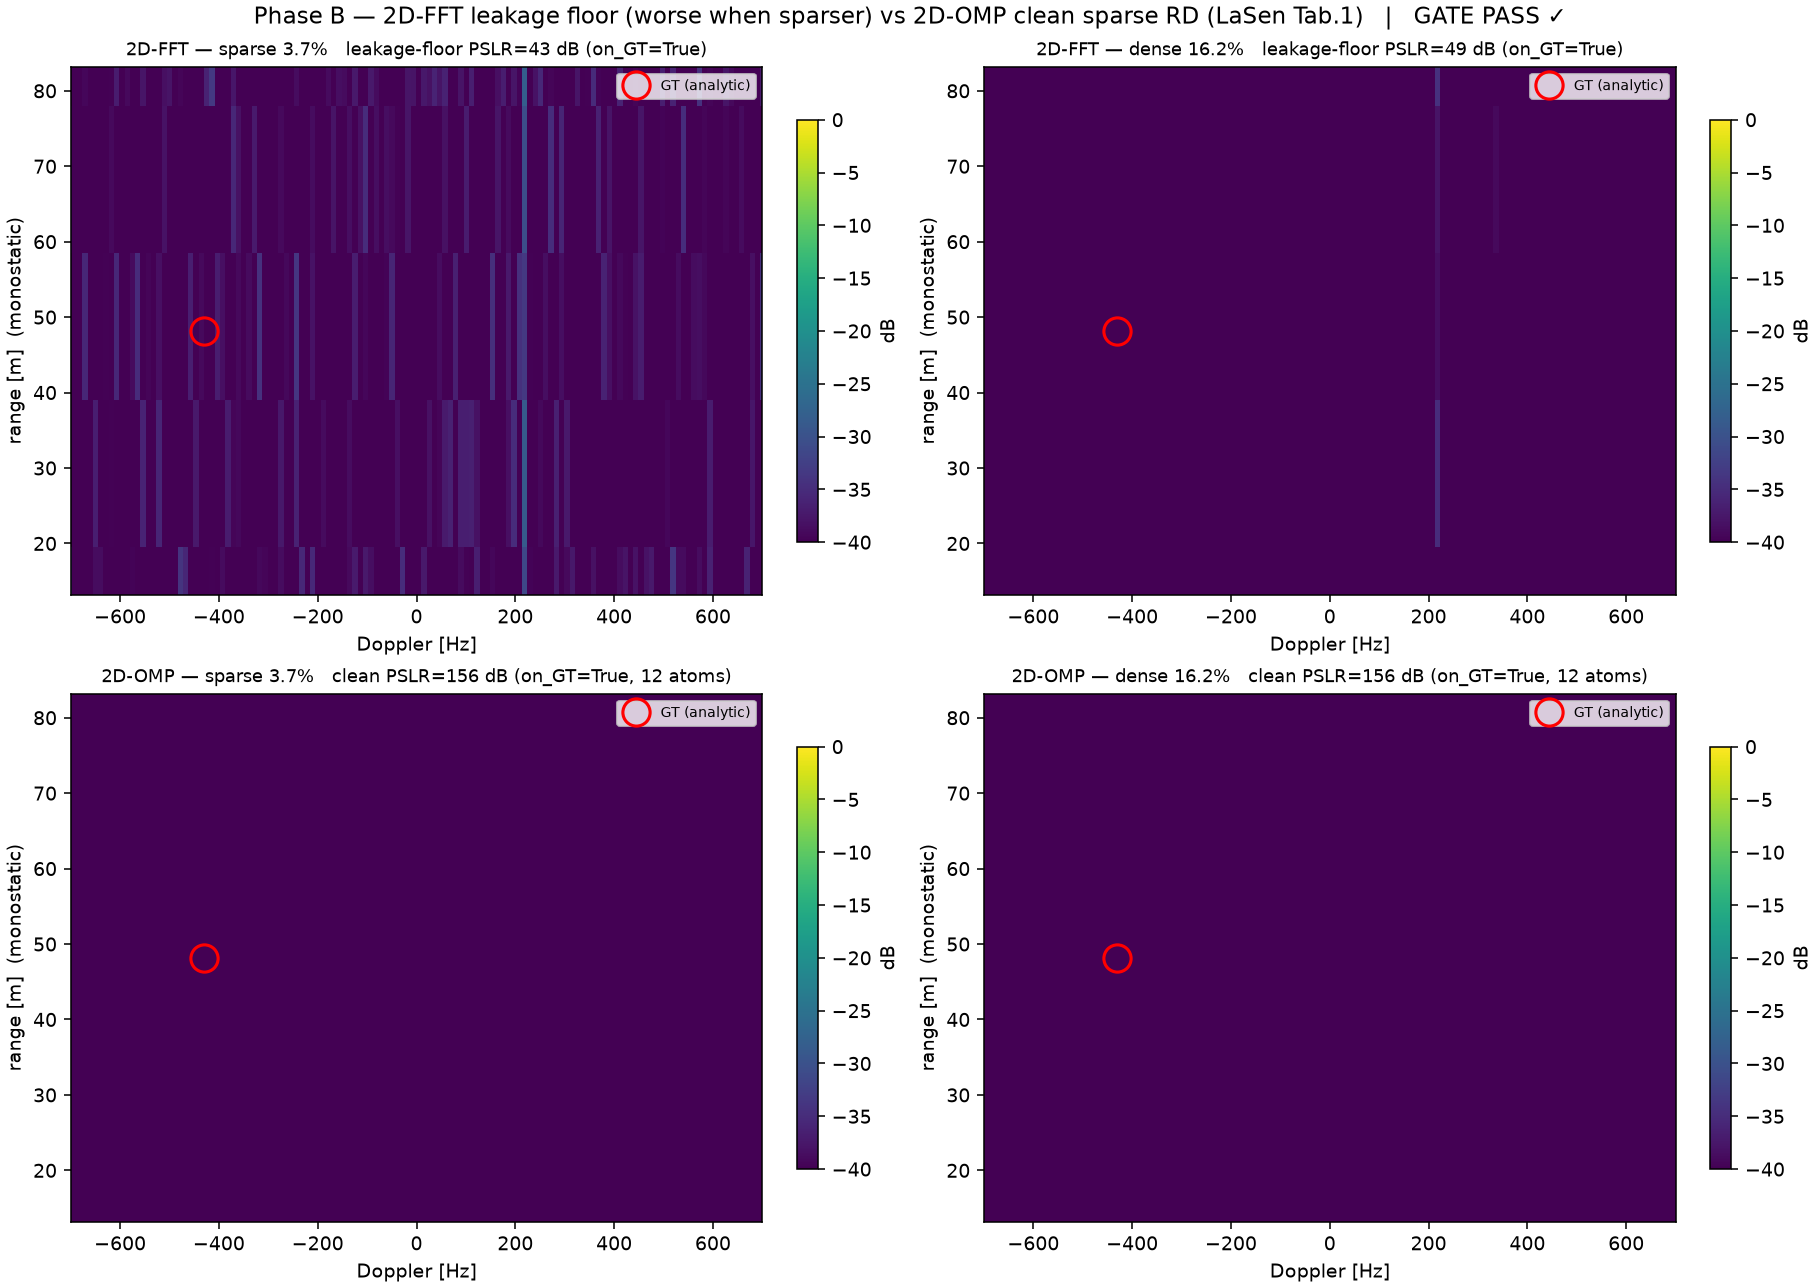
*왜:* 단일 표적은 OMP 1st atom = FFT 피크라 **피크 위치는 같다**(둘 다 on_GT). 차이는 **동적범위** — FFT는 sparse에서 누설바닥 PSLR 43 dB(약한 표적이 묻힘), OMP는 156 dB(노이즈 바닥까지 깨끗). 이게 LaSen sparse recovery가 FFT를 이기는 이유.

### 2D-OMP 수렴 (잔차 norm vs iter)
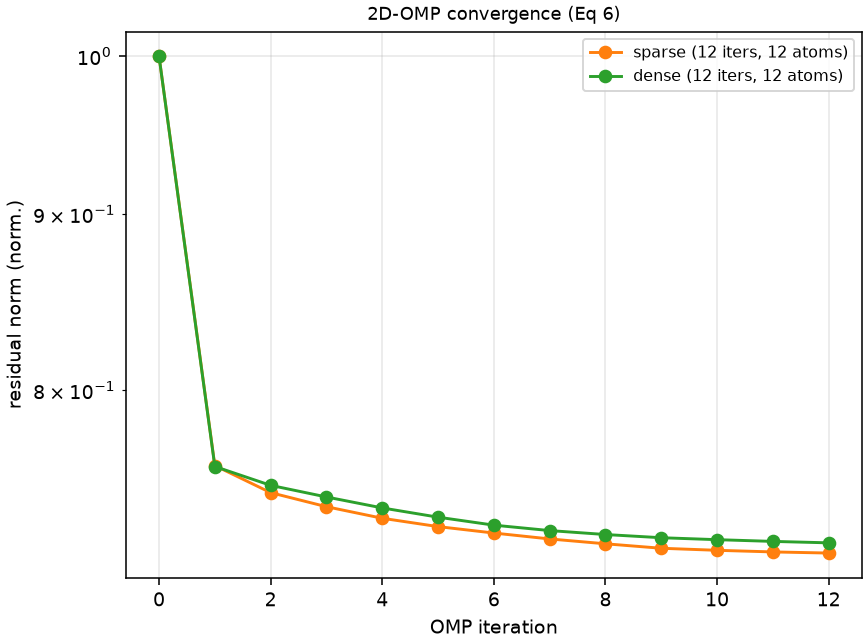
*왜:* OMP가 강한 표적을 먼저 잡고 잔차를 줄임(atoms sparse 12 / dense 12). RT 드론은 완전 단일 atom이 아니라(다중경로 spread) 몇 개 atom으로 적합됨.

→ **GATE ✅ PASS.** 다음 = Phase C(ID score + global/local + Kalman 추적).

_정직 노트: 단일 표적이라 'OMP만 표적을 본다'는 못 보임(둘 다 본다) — 차이는 **누설바닥/동적범위**. 약한-2nd-표적 동적범위 데모는 RT 드론 spread에 가려 후속 과제. slow-time는 OMP 가용성 위해 256 심볼로 subsample(Phase A는 full 2803). 상세: `docs/FAITHFULNESS.md`._